In [14]:
import nibabel as nib
from pathlib import Path
from sklearn.metrics import davies_bouldin_score, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from tqdm import tqdm


random_state = 42

# Introduction


# Settings

In [15]:
# Folders
DATASET_PATH = Path("/home/guoqiu/NAS/HCP/HCP_3T/HCP_3T_REST/HCP_3T_MNINonLinear")

DATA_PATH = Path('../data')
RESULT_PATH = Path('../results')

In [16]:
SUBJECT_LIST_FILE = DATA_PATH / 'HCP_3T.tsv'
SUBJECT_LIST = pd.read_csv(SUBJECT_LIST_FILE)['participant_id'].values.tolist()

LEFT_MEDIAL_WALL_MASK_FILE = DATA_PATH / 'medialwall.mask.leftcortex.csv'
LEFT_unROI_MASK = pd.read_csv(LEFT_MEDIAL_WALL_MASK_FILE, header=None, dtype=bool).values[:, 0]

RIGHT_MEDIAL_WALL_MASK_FILE = DATA_PATH / 'medialwall.mask.rightcortex.csv'
RIGHT_unROI_MASK = pd.read_csv(RIGHT_MEDIAL_WALL_MASK_FILE, header=None, dtype=bool).values[:, 0]

LEFT_ROI_IMAGE = nib.load(DATA_PATH / 'VMPFC_surface.L.func.gii')
LEFT_ROI_MASK = np.logical_and(LEFT_ROI_IMAGE.agg_data() > 0, LEFT_unROI_MASK)
RIGHT_ROI_IMAGE = nib.load(DATA_PATH / 'VMPFC_surface.R.func.gii')
RIGHT_ROI_MASK = np.logical_and(RIGHT_ROI_IMAGE.agg_data() > 0, RIGHT_unROI_MASK)

N_CLUSTERS_LIST = list(range(2, 7))

# Run

## Left Hemisphere
### Make Cross Correlation Matrix

In [21]:
# ROI_data = np.concatenate([left_ROI_data, right_ROI_data], axis=1).T
ROI_data = np.array(left_ROI_data).T
print(f'ROI: (n voxels, n subjects) = {ROI_data.shape}')
# unROI_data = np.concatenate([left_unROI_data, right_unROI_data], axis=1).T
unROI_data = np.array(left_unROI_data).T
print(f'unROI: (n voxels, n subjects) = {unROI_data.shape}')

connectivity = pairwise_distances(ROI_data, unROI_data, metric='correlation').T
print(f'connectivity: (n unROI voxels, n ROI voxels) = {connectivity.shape}')
assert not np.isnan(connectivity).any(), "There are NaNs in connectivity!"

cross_correlation = np.corrcoef(connectivity, rowvar=False)
print(f'cross_correlation: (n ROI voxels, n ROI voxels) = {cross_correlation.shape}')
assert not np.isnan(cross_correlation).any(), "There are NaNs in cross_correlation!"

ROI: (n voxels, n subjects) = (338, 667)
unROI: (n voxels, n subjects) = (29696, 667)
connectivity: (n unROI voxels, n ROI voxels) = (29696, 338)
cross_correlation: (n ROI voxels, n ROI voxels) = (338, 338)


### K-Means Parcellation

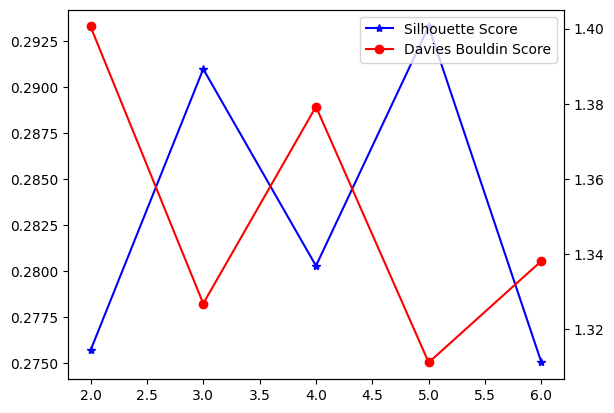

In [22]:
label_dict = {
    n_clusters:
        KMeans(
            n_clusters=n_clusters,
            init='random',
            n_init=1000,
            random_state=random_state,
        ).fit_predict(cross_correlation) + 1
    for n_clusters in N_CLUSTERS_LIST
}


# Validity measure of clusters - higher is better
SS_scores = [silhouette_score(cross_correlation, label) for label in label_dict.values()]
DBI_scores = [davies_bouldin_score(cross_correlation, label) for label in label_dict.values()]
scores_df = pd.DataFrame(dict(silhouette_scores=SS_scores, davies_bouldin_scores=DBI_scores))
scores_df.index = N_CLUSTERS_LIST
scores_df.index.name = 'n_clusters'
scores_df.to_csv(RESULT_PATH / 'internal_validity/Myelination_HCP_3T.csv')
# fast plot for the scores
line1, = plt.plot(N_CLUSTERS_LIST, SS_scores, 'b-*', )
plt.twinx()
line2, = plt.plot(N_CLUSTERS_LIST, DBI_scores, 'ro-', )
plt.legend([line1, line2], ['Silhouette Score', 'Davies Bouldin Score'])

In [23]:
n_left_roi_vertices = np.sum(LEFT_ROI_MASK)
n_left_total_vertices = len(LEFT_ROI_MASK)

for n_clusters in N_CLUSTERS_LIST:
    labels = label_dict[n_clusters]
    labels_left = labels[:n_left_roi_vertices]
    left_cluster_map = np.zeros(n_left_total_vertices, dtype=np.int32)
    left_cluster_map[LEFT_ROI_MASK] = labels_left
    left_darray = nib.gifti.GiftiDataArray(left_cluster_map, intent='NIFTI_INTENT_LABEL', datatype='NIFTI_TYPE_INT32')
    left_gii_image = nib.gifti.GiftiImage(darrays=[left_darray])
    output_filename_left = RESULT_PATH / 'gii' / f'Myelination_HCP_3T_K{n_clusters}.func.gii'
    nib.save(left_gii_image, output_filename_left)

## Right Hemisphere
### Make Cross Correlation Matrix

In [24]:
# ROI_data = np.concatenate([right_ROI_data, right_ROI_data], axis=1).T
ROI_data = np.array(right_ROI_data).T
print(f'ROI: (n voxels, n subjects) = {ROI_data.shape}')
# unROI_data = np.concatenate([right_unROI_data, right_unROI_data], axis=1).T
unROI_data = np.array(right_unROI_data).T
print(f'unROI: (n voxels, n subjects) = {unROI_data.shape}')

connectivity = pairwise_distances(ROI_data, unROI_data, metric='correlation').T
print(f'connectivity: (n unROI voxels, n ROI voxels) = {connectivity.shape}')
assert not np.isnan(connectivity).any(), "There are NaNs in connectivity!"

cross_correlation = np.corrcoef(connectivity, rowvar=False)
print(f'cross_correlation: (n ROI voxels, n ROI voxels) = {cross_correlation.shape}')
assert not np.isnan(cross_correlation).any(), "There are NaNs in cross_correlation!"

ROI: (n voxels, n subjects) = (310, 667)
unROI: (n voxels, n subjects) = (29716, 667)
connectivity: (n unROI voxels, n ROI voxels) = (29716, 310)
cross_correlation: (n ROI voxels, n ROI voxels) = (310, 310)


### K-Means Parcellation

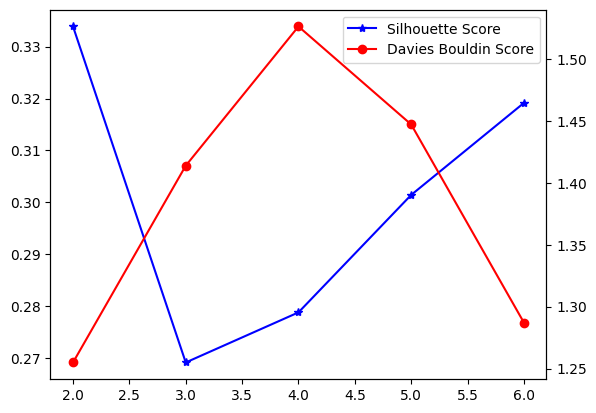

In [25]:
label_dict = {
    n_clusters:
        KMeans(
            n_clusters=n_clusters,
            init='random',
            n_init=1000,
            random_state=random_state,
        ).fit_predict(cross_correlation) + 1
    for n_clusters in N_CLUSTERS_LIST
}
# Validity measure of clusters - higher is better
SS_scores = [silhouette_score(cross_correlation, label) for label in label_dict.values()]
DBI_scores = [davies_bouldin_score(cross_correlation, label) for label in label_dict.values()]
scores = dict(silhouette_scores=SS_scores, davies_bouldin_scores=DBI_scores)
# joblib.dump(scores, RESULT_FOLDER / 'scores.list', )
# fast plot for the scores
line1, = plt.plot(N_CLUSTERS_LIST, SS_scores, 'b-*', )
plt.twinx()
line2, = plt.plot(N_CLUSTERS_LIST, DBI_scores, 'ro-', )
plt.legend([line1, line2], ['Silhouette Score', 'Davies Bouldin Score'])

In [26]:
n_right_roi_vertices = np.sum(RIGHT_ROI_MASK)
n_right_total_vertices = len(RIGHT_ROI_MASK)

for n_clusters in N_CLUSTERS_LIST:
    labels = label_dict[n_clusters]
    labels_right = labels[:n_right_roi_vertices]
    right_cluster_map = np.zeros(n_right_total_vertices, dtype=np.int32)
    right_cluster_map[RIGHT_ROI_MASK] = labels_right
    right_darray = nib.gifti.GiftiDataArray(right_cluster_map, intent='NIFTI_INTENT_LABEL', datatype='NIFTI_TYPE_INT32')
    right_gii_image = nib.gifti.GiftiImage(darrays=[right_darray])
    output_filename_right = RESULT_PATH / 'gii' / f'Myelination_HCP_3T_K{n_clusters}_R.func.gii'
    nib.save(right_gii_image, output_filename_right)